### Importing packages

In [86]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
from consts import *


## Constants
vg = C/NG # group velocity
alpha_tot = ALPHA_INT + 0.5*np.log(1/(R*R))/L # total alpha loss
V = L * D * W # volume of the diode
tau_ph = 1/(vg*alpha_tot) # photon lifetime 
g_th = alpha_tot / GAMMA; # gain 
q = 1.6*1e-19 # electric charge

lamda = 1.55e-4 # operating wavelength (assumed to be 1.55um)
freq = C/lamda

# Task B: Static (L-I) Characteristcs

## Practical

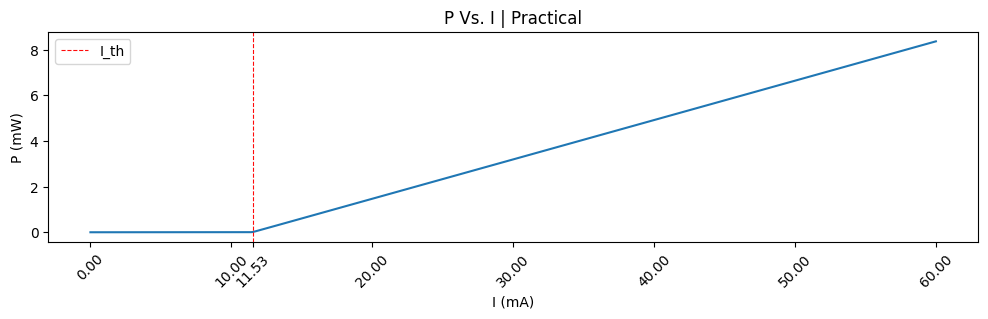

In [87]:
# diff equation input for odeint function
def dydt(y,t,current):
    N, S = y
    gain = B * max(N - N0, 0)
    injection =current/(q*V)
    dndt =injection-(N/TAU)-GAMMA*C*gain*S
    dsdt = GAMMA*C*gain*S-(S/tau_ph)+(BETA_SP* N /TAU)
    return [dndt, dsdt]

N_sweep = 1000
th = 0
I = np.linspace(0, 60e-3, N_sweep)
P = np.zeros(N_sweep)
th = 0

for i in range(N_sweep):
    t1=np.linspace(0,1e-9,2000)
    t2=np.linspace(1e-9,20e-9,10000)
    initial_conditions_1 =[0,0]
    soln1= odeint(dydt, initial_conditions_1,t1, args=(0.0,))
    initial_conditions_2 =soln1[-1,:]
    soln2=odeint(dydt, initial_conditions_2,t2,args=(I[i],))
    t_total= np.concatenate((t1, t2))
    soln_total= np.vstack((soln1, soln2))
    N_t=soln_total[:,0]
    S_t=soln_total[:,1]
    P[i] = 0.5*np.log(1/R)*H*freq*vg*D*W*S_t[-1]
    if (P[i] - P[i-1]) / ((I[i] - I[i-1])) > 3000*(P[1] - P[0]) / ((I[1] - I[0])) and i > 1 and th <= 0:
        th = i


plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(I*1e3, P*1e3)
plt.xlabel("I (mA)")
plt.ylabel("P (mW)")
plt.axvline(I[th]*1e3, ls='--', lw=0.8, color='r', alpha=0.96, label='I_th')
plt.title("P Vs. I | Practical")
plt.xticks([0, 10, I[th]*1e3, 20, 30, 40, 50, 60], rotation=45)
plt.legend()
plt.show()



## Theoritical 

### Defining variables

In [88]:
Nth = g_th/B + N0   # carrier density at threshold
Jth = Nth * E * D / TAU  # current density at threshold
Ith = Jth * L * W  # threshold current

### Defining current and power axes

In [89]:
i = np.linspace(0, 60e-3, int(1e4)) # current injection access
eta = ((np.log(1/R)*H*C*vg*tau_ph)/(2*L*E*lamda))
Ps = ((BETA_SP * tau_ph*Nth*H*C*vg*V*np.log(1/R))/(2*L*lamda*TAU))
p = np.zeros(len(i))
for k in range(0, len(i)):
    if eta*(i[k] - Ith) + Ps < Ps:
        p[k] = Ps
    else:
        p[k] = eta*(i[k]-Ith)+Ps # pout = eta(i-ith) + ps

### Plotting results

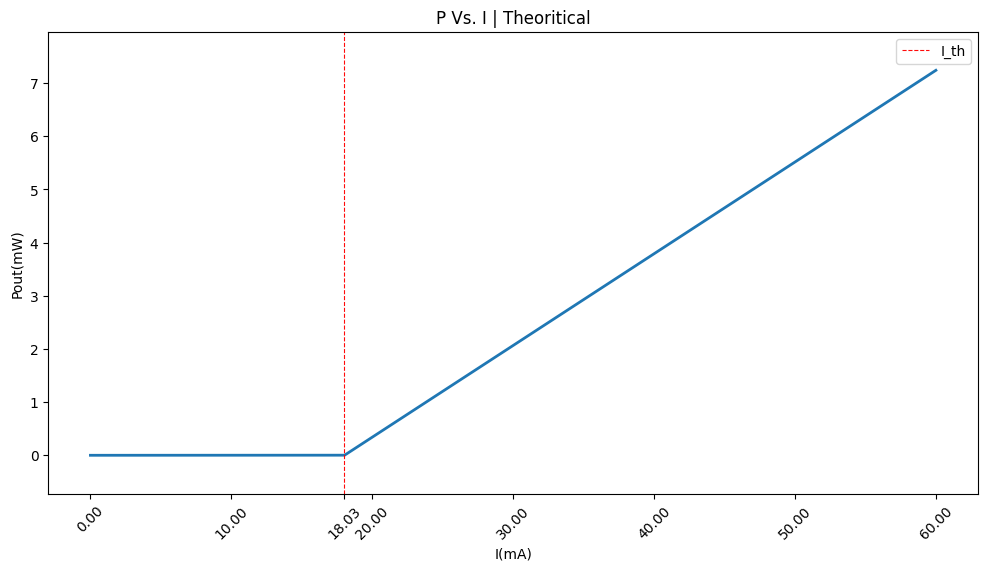

In [90]:
plt.figure(figsize=(12, 6))
plt.plot(i*1e3, p*1e3, lw=2)
plt.title('P Vs. I | Theoritical')
plt.ylabel('Pout(mW)')
plt.xlabel('I(mA)')
plt.ylim([-0.1*max(p*1e3), 1.1*max(p*1e3)])
plt.axvline(Ith*1e3, ls='--', lw=0.8, color='r', alpha=0.96, label='I_th')
plt.xticks([0, 10, Ith*1e3, 20, 30, 40, 50, 60], rotation=45)
plt.legend()
plt.show()